In [1]:
import pandas as pd
import os


PATH = "/scratch/am10150/projects/MindEyeV2/src/evals/rtnorm_subj1_datascaling"
folders = [
    "finetuned_subj01_139_trials_avg_1",
    "finetuned_subj01_277_trials_avg_1",
    "finetuned_subj01_693_trials_avg_1",
    "finetuned_subj01_1386_trials_avg_1",
    "finetuned_subj01_3_sessions_avg_1",
    "finetuned_subj01_5_sessions_avg_1",
    "finetuned_subj01_10_sessions_avg_1",
    "finetuned_subj01_20_sessions_avg_1",
    # "finetuned_subj01_40_sessions_avg_1",
]

times = [
    f"11 min",
    f"22 min",
    f"55 min",
    f"108 min",
    f"{3 * 1} hrs",
    f"{5 * 1} hrs",
    f"{10 * 1} hrs",
    f"{20 * 1} hrs",
    # f"{40 * 1} hrs",
]

METRICS = [
    'fwd_acc',
    'bwd_acc',
    'pixcorr',
    'ssim',
    'alexnet2',
    'alexnet5',
    'inception',
    'clip_',
    'effnet',
    'swav',
]

METRICS2Names = {
    "fwd_acc": "Image Retrieval",
    "bwd_acc": "Brain Retrieval",
    "pixcorr": "PixCorr",
    "ssim": "SSIM",
    "alexnet2": "AlexNet(2)",
    "alexnet5": "AlexNet(5)",
    "inception": "InceptionV3",
    "clip_": "CLIP",
    "effnet": "EffNet-B",
    "swav": "SwAV",
}

metrics = []
for idx, folder in enumerate(folders):
    if os.path.isdir(os.path.join(PATH, folder)) is False or ".ipynb_checkpoints" in folder:
        continue
    print(folder)
    data_size = folder.split("subj01_")[-1].split("_avg_1")[0]
    print(data_size)

    metrics_df = pd.read_csv(os.path.join(PATH, folder, "0/metrics.csv"))
    
    metrics_df = metrics_df.pivot_table(columns="metric", values="values").reset_index().drop(columns=["index"])
    metrics_df = metrics_df[METRICS]
    metrics_df["time"] = times[idx]
    metrics.append(metrics_df)
    

finetuned_subj01_139_trials_avg_1
139_trials
finetuned_subj01_277_trials_avg_1
277_trials
finetuned_subj01_693_trials_avg_1
693_trials
finetuned_subj01_1386_trials_avg_1
1386_trials
finetuned_subj01_3_sessions_avg_1
3_sessions
finetuned_subj01_5_sessions_avg_1
5_sessions
finetuned_subj01_10_sessions_avg_1
10_sessions
finetuned_subj01_20_sessions_avg_1
20_sessions


In [2]:
metrics = pd.concat(metrics)

In [3]:
metrics

metric,fwd_acc,bwd_acc,pixcorr,ssim,alexnet2,alexnet5,inception,clip_,effnet,swav,time
0,0.26,0.18,0.107700,0.307334,0.584082,0.661633,0.530612,0.582449,0.948486,0.560040,11 min
0,0.30,0.24,0.120248,0.313056,0.648163,0.749796,0.588571,0.559592,0.945449,0.567879,22 min
0,0.40,0.44,0.064257,0.310865,0.686122,0.742449,0.637959,0.628571,0.923512,0.541401,55 min
0,0.38,0.46,0.129612,0.301703,0.702041,0.809796,0.655510,0.657551,0.920071,0.533494,108 min
0,0.50,0.56,0.104819,0.282040,0.702449,0.811020,0.660408,0.678776,0.906612,0.539153,3 hrs
0,0.60,0.62,0.113552,0.292213,0.712653,0.819184,0.715918,0.675510,0.864600,0.501957,5 hrs
0,0.66,0.64,0.146558,0.282192,0.728980,0.818776,0.697959,0.641224,0.879599,0.506680,10 hrs
0,0.72,0.64,0.118847,0.271727,0.734694,0.830204,0.740000,0.701633,0.890060,0.527608,20 hrs


In [4]:
metric_maxs = {
}
agg_ri = metrics.copy()

# decreasing metrics
DESC_METRICS = ["effnet", "swav"]
for desc_met in DESC_METRICS:
    agg_ri[desc_met] = 1 - agg_ri[desc_met]

for metric in METRICS:
    metric_max = agg_ri[metric].max()
    agg_ri[metric] = agg_ri[metric].apply(lambda x: x / metric_max)


In [5]:
agg_ri

metric,fwd_acc,bwd_acc,pixcorr,ssim,alexnet2,alexnet5,inception,clip_,effnet,swav,time
0,0.361111,0.28125,0.734863,0.981722,0.795000,0.796952,0.717044,0.830134,0.380455,0.883378,11 min
0,0.416667,0.37500,0.820483,1.000000,0.882222,0.903147,0.795367,0.797557,0.402889,0.867639,22 min
0,0.555556,0.68750,0.438440,0.993004,0.933889,0.894297,0.862107,0.895870,0.564904,0.920802,55 min
0,0.527778,0.71875,0.884377,0.963737,0.955556,0.975418,0.885825,0.937173,0.590314,0.936678,108 min
0,0.694444,0.87500,0.715205,0.900925,0.956111,0.976893,0.892443,0.967423,0.689721,0.925316,3 hrs
0,0.833333,0.96875,0.774795,0.933422,0.970000,0.986726,0.967457,0.962769,1.000000,1.000000,5 hrs
0,0.916667,1.00000,1.000000,0.901411,0.992222,0.986234,0.943188,0.913903,0.889222,0.990518,10 hrs
0,1.000000,1.00000,0.810925,0.867982,1.000000,1.000000,1.000000,1.000000,0.811965,0.948496,20 hrs


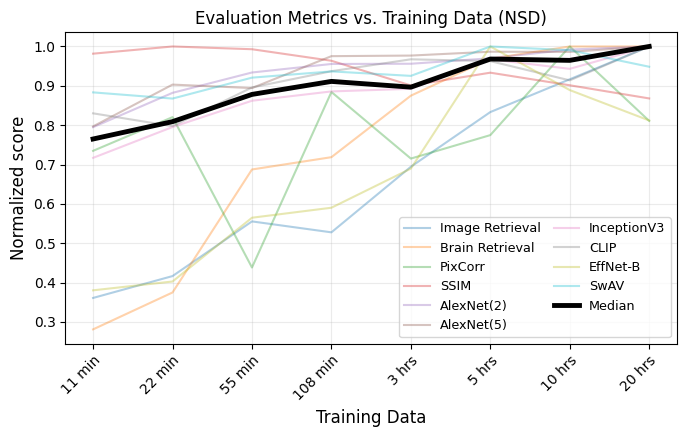

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

# --- Global style to match the image ---
mpl.rcParams.update({
    "font.family": "sans-serif",      # <--- SWITCHED TO SANS-SERIF
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
})

# --- DEMO DATA GENERATION ---
np.random.seed(42)
x_vals = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
data = {"data_size": x_vals}
metric_names = ["fwd_acc", "bwd_acc", "pixcorr", "ssim", 
                "alexnet2", "alexnet5", "inception", "clip_", "effnet", "swav"]

# --- CALCULATE MEAN ---
# agg_ri["minutes"] = agg_ri["data_size"].astype(int).astype(str) + " min."
metric_cols = [c for c in agg_ri.columns if c not in ["metric", "time"]]
# agg_ri["Median"] = agg_ri[metric_cols].median(axis=1)

# Calculate the row-wise Median (across all metrics for each x-value)
agg_ri["Median"] = agg_ri[metric_cols].median(axis=1)


# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(7, 4.5)) 

# 1. Plot the "Background" lines (Individual Metrics)
colors = plt.cm.tab10.colors 

for i, col in enumerate(metric_cols):
    ax.plot(
        agg_ri["time"],
        agg_ri[col],
        label=METRICS2Names.get(col, col),
        color=colors[i % len(colors)],
        linewidth=1.5,
        alpha=0.35,       # Faint background lines
        marker="",        
    )

# 2. Plot the "Highlight" line (The Mean)
ax.plot(
    agg_ri["time"],
    agg_ri["Median"],       # Using the Mean column
    label="Median",         # Updated label
    color="black",        
    linewidth=3.5,        
    markersize=5,
    zorder=10             
)

# --- CLEANING UP THE LOOK ---
# # 1. Remove Grid Lines
# ax.grid(False) 

# 2. Remove Bottom Ticks (keep labels)
# ax.tick_params(axis="x", bottom=False)  # <--- Removes the little black lines

# Labels & Title
ax.set_title("Evaluation Metrics vs. Training Data (NSD)")
ax.set_xlabel("Training Data")
ax.set_ylabel("Normalized score")

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Legend
ax.legend(
    frameon=True,
    loc="lower right",
    ncol=2,             # <--- Key change to make it short and wide
    fontsize="small",   # <--- Key change to save space
    columnspacing=1.0   # Adjust gap between columns
)

# Layout
plt.tight_layout()

# --- Export ---
plt.savefig("results_data_scaling_nsdv2.png", bbox_inches="tight")
plt.show()